# Rare word / vocab coverage EDA

How many distinct words do we need to keep to cover 95% of word *occurrences*
(frequency mass) in each split (train / dev / test)?

This is frequency-mass coverage, not PCA "variance" -- word counts have no natural variance
decomposition, so the analogous idea is: sort words by frequency, take cumulative share of
total token occurrences, find how many distinct words it takes to cross 95%.

Splits used (from `data/`, the `[NEW] Train Dev Test cleaned` set):
- `train_final.src.tok` (zipped in `train_final.zip`) -- training corpus, one sentence per line
- `dev_set_final.csv` -- `context` column (dev)
- `test_set_no_answer_final.csv` -- `context` column, no answer

In [1]:
from collections import Counter
from pathlib import Path
import csv

DATA = Path("../data")

In [2]:
def count_corpus_zip(path, member):
    """Word counts for a one-sentence-per-line token file zipped inside path."""
    import zipfile, io
    c = Counter()
    with zipfile.ZipFile(path) as zf:
        with io.TextIOWrapper(zf.open(member), encoding="utf-8") as f:
            for line in f:
                c.update(line.split())
    return c


def count_context_csv(path):
    """Word counts for the 'context' column of a cleaned csv."""
    c = Counter()
    with open(path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            c.update(row["context"].split())
    return c

In [3]:
counts = {
    "train": count_corpus_zip(DATA / "train_final.zip", "train_final.src.tok"),
    "dev": count_context_csv(DATA / "dev_set_final.csv"),
    "test_no_answer": count_context_csv(DATA / "test_set_no_answer_final.csv"),
}
for name, c in counts.items():
    print(f"{name}: {len(c):,} distinct words, {sum(c.values()):,} total occurrences")

train: 99,018 distinct words, 126,652,466 total occurrences
dev: 44,321 distinct words, 2,321,700 total occurrences
test_no_answer: 44,448 distinct words, 2,325,294 total occurrences


## Coverage: words needed for 95% of occurrences

Sort words by frequency descending, accumulate, stop once cumulative share crosses the
threshold.

In [4]:
def coverage_table(counter, thresholds=(0.90, 0.95, 0.99)):
    total = sum(counter.values())
    freqs = sorted(counter.values(), reverse=True)
    cum = 0
    n_at = {}
    remaining = list(thresholds)
    for i, f in enumerate(freqs, start=1):
        cum += f
        while remaining and cum / total >= remaining[0]:
            n_at[remaining.pop(0)] = i
        if not remaining:
            break
    for t in remaining:  # threshold never reached (shouldn't happen at <=99%)
        n_at[t] = len(freqs)
    return n_at, len(freqs), total


rows = []
for name, c in counts.items():
    n_at, vocab_size, total = coverage_table(c)
    row = {"split": name, "vocab_size": vocab_size, "total_tokens": total}
    for t, n in n_at.items():
        row[f"words_for_{int(t*100)}pct"] = n
        row[f"pct_of_vocab_{int(t*100)}"] = round(100 * n / vocab_size, 2)
    rows.append(row)

import pandas as pd
df = pd.DataFrame(rows).set_index("split")
df


,vocab_size,total_tokens,words_for_90pct,pct_of_vocab_90,words_for_95pct,pct_of_vocab_95,words_for_99pct,pct_of_vocab_99
split,,,,,,,,
train,99018,126652466,4369,4.41,9120,9.21,30810,31.12
dev,44321,2321700,4414,9.96,8942,20.18,25482,57.49
test_no_answer,44448,2325294,4415,9.93,8956,20.15,25541,57.46


## Threshold cliff: words needed vs. coverage target

Push the threshold higher (90% -> 99.9%) and see where words-needed stops being worth it --
the long tail of singletons makes the last few percent disproportionately expensive.

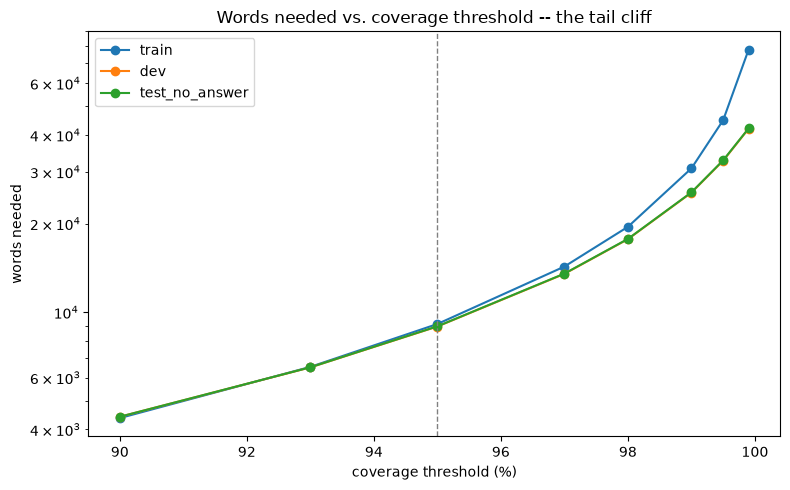

In [5]:
import matplotlib.pyplot as plt

fine_thresholds = [0.90, 0.93, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999]

fig, ax = plt.subplots(figsize=(8, 5))
for name, c in counts.items():
    n_at, vocab_size, total = coverage_table(c, fine_thresholds)
    xs = [t * 100 for t in fine_thresholds]
    ys = [n_at[t] for t in fine_thresholds]
    ax.plot(xs, ys, marker="o", label=name)

ax.axvline(95, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("coverage threshold (%)")
ax.set_ylabel("words needed")
ax.set_yscale("log")
ax.set_title("Words needed vs. coverage threshold -- the tail cliff")
ax.legend()
plt.tight_layout()
plt.show()

## Cumulative coverage curve

Rank (log scale) vs. cumulative share of occurrences. Marks the 95% line and how many words
it takes to reach it, per split.

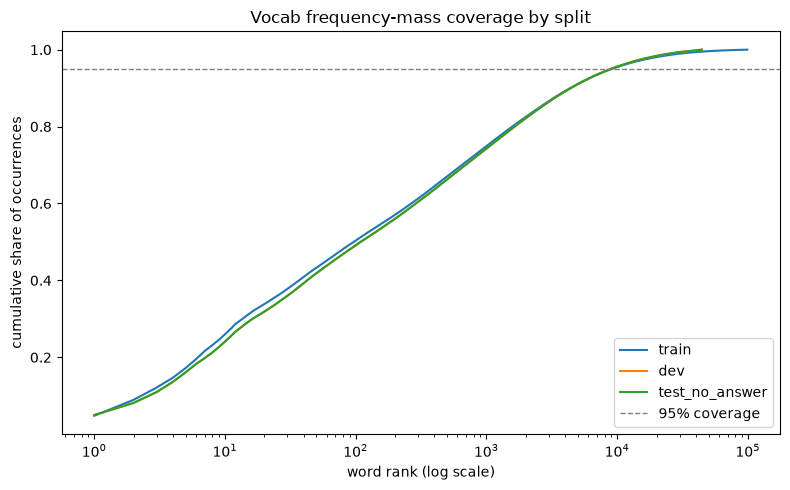

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for name, c in counts.items():
    freqs = sorted(c.values(), reverse=True)
    total = sum(freqs)
    cum = []
    running = 0
    for f in freqs:
        running += f
        cum.append(running / total)
    ax.plot(range(1, len(cum) + 1), cum, label=name)

ax.axhline(0.95, color="gray", linestyle="--", linewidth=1, label="95% coverage")
ax.set_xscale("log")
ax.set_xlabel("word rank (log scale)")
ax.set_ylabel("cumulative share of occurrences")
ax.set_title("Vocab frequency-mass coverage by split")
ax.legend()
plt.tight_layout()
plt.show()


## Rarest words

Long tail: how many words occur only once (hapax legomena) per split -- these are the ones a
frequency-coverage vocab cutoff drops first.

In [7]:
for name, c in counts.items():
    hapax = sum(1 for v in c.values() if v == 1)
    print(f"{name}: {hapax:,} hapax legomena "
          f"({100*hapax/len(c):.1f}% of distinct words, {100*hapax/sum(c.values()):.3f}% of occurrences)")


train: 3 hapax legomena (0.0% of distinct words, 0.000% of occurrences)
dev: 14,461 hapax legomena (32.6% of distinct words, 0.623% of occurrences)
test_no_answer: 14,563 hapax legomena (32.8% of distinct words, 0.626% of occurrences)


## Words in dev/test but missing from train vocab

Context vocab words the model can never have learned an embedding/count for. Also load
`dev_set_final.csv`'s `answer` column, since answer words (not just context) are what
actually get predicted.

In [8]:
train_vocab = set(counts["train"].keys())

dev_answer_vocab = set()
with open(DATA / "dev_set_final.csv", newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        dev_answer_vocab.add(row["answer"])

for name, vocab in [
    ("dev context", set(counts["dev"].keys())),
    ("dev answer", dev_answer_vocab),
    ("test context", set(counts["test_no_answer"].keys())),
]:
    missing = sorted(vocab - train_vocab)
    print(f"{name}: {len(missing)}/{len(vocab)} words missing from train -- {missing}")

dev context: 0/44321 words missing from train -- []
dev answer: 2/10308 words missing from train -- ['[', ']']
test context: 1/44448 words missing from train -- ['[']


## Bracket tokens: `[` / `]` and PTB placeholders (`-lrb-`, `-rsb-`, etc.)

Missing words above are just `[` and `]`. Check: does train ever see a raw bracket char as a
token, or a PTB-style placeholder (`-lrb-`/`-rrb-`/`-lsb-`/`-rsb-`/`-lcb-`/`-rcb-`) instead --
and do dev/test actually contain these as tokens (not just as an isolated `first letter` field)?

In [9]:
bracket_toks = ["[", "]", "-lrb-", "-rrb-", "-lsb-", "-rsb-", "-lcb-", "-rcb-", "[UNK]"]

print("train counts:")
for tok in bracket_toks:
    print(f"  {tok!r}: {counts['train'].get(tok, 0):,}")

print("\ndev context counts:")
for tok in bracket_toks:
    print(f"  {tok!r}: {counts['dev'].get(tok, 0):,}")

print("\ntest context counts:")
for tok in bracket_toks:
    print(f"  {tok!r}: {counts['test_no_answer'].get(tok, 0):,}")

# answer-side: how often is the actual answer literally "[" or "]"?
dev_ans_bracket = Counter()
with open(DATA / "dev_set_final.csv", newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        if row["answer"] in ("[", "]"):
            dev_ans_bracket[row["answer"]] += 1
print("\ndev answer == '[' or ']':", dict(dev_ans_bracket))

train counts:
  '[': 0
  ']': 0
  '-lrb-': 0
  '-rrb-': 0
  '-lsb-': 0
  '-rsb-': 0
  '-lcb-': 0
  '-rcb-': 0
  '[UNK]': 414,394

dev context counts:
  '[': 0
  ']': 0
  '-lrb-': 0
  '-rrb-': 0
  '-lsb-': 0
  '-rsb-': 0
  '-lcb-': 0
  '-rcb-': 0
  '[UNK]': 10,206

test context counts:
  '[': 47
  ']': 0
  '-lrb-': 0
  '-rrb-': 0
  '-lsb-': 0
  '-rsb-': 0
  '-lcb-': 0
  '-rcb-': 0
  '[UNK]': 10,223



dev answer == '[' or ']': {']': 61, '[': 63}


**Conclusion:** train never has a raw `[`/`]` token, and none of the PTB placeholders
(`-lrb-` etc.) exist anywhere in this dataset -- train collapses every bracket occurrence into
`[UNK]` instead, losing which bracket it was. dev/test keep the literal `[`/`]` character as
the answer/context token, so the model has zero training signal to ever emit `[` or `]` --
this is a genuine train/dev-test tokenization mismatch, not just a rare-word gap.

## Number tokens: how are numbers actually represented?

`categorize()`-style number tokens (`[0-9]+`) -- check if these are real numbers or an
anonymization scheme (digit-length placeholders).

In [10]:
import re

num_pattern = re.compile(r"[0-9]+")

def number_report(name, c):
    num_toks = sorted((t for t in c if num_pattern.fullmatch(t)), key=lambda t: -c[t])
    non_repdigit = [t for t in num_toks if len(set(t)) > 1]
    total = sum(c[t] for t in num_toks)
    print(f"{name}: {len(num_toks)} distinct number tokens, {total:,} occurrences "
          f"({100*total/sum(c.values()):.2f}% of all tokens)")
    print(f"  tokens (by freq): {[(t, c[t]) for t in num_toks]}")
    print(f"  non-repeated-digit tokens (i.e. not a length placeholder like '111'): {non_repdigit}")

for name, c in counts.items():
    number_report(name, c)
    print()

dev_answer_counts = Counter()
with open(DATA / "dev_set_final.csv", newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        dev_answer_counts[row["answer"]] += 1
number_report("dev answer", dev_answer_counts)

train: 8 distinct number tokens, 2,622,531 occurrences (2.07% of all tokens)
  tokens (by freq): [('11', 1017456), ('1', 865577), ('111', 492745), ('1111', 246093), ('11111', 578), ('111111', 60), ('11111111', 12), ('1111111', 10)]
  non-repeated-digit tokens (i.e. not a length placeholder like '111'): []

dev: 7 distinct number tokens, 52,363 occurrences (2.26% of all tokens)
  tokens (by freq): [('11', 19922), ('1', 17997), ('111', 10088), ('1111', 4345), ('11111', 7), ('1111111', 3), ('111111', 1)]
  non-repeated-digit tokens (i.e. not a length placeholder like '111'): []

test_no_answer: 7 distinct number tokens, 52,546 occurrences (2.26% of all tokens)
  tokens (by freq): [('11', 20146), ('1', 17734), ('111', 10174), ('1111', 4489), ('11111', 1), ('1111111', 1), ('111111', 1)]
  non-repeated-digit tokens (i.e. not a length placeholder like '111'): []



dev answer: 4 distinct number tokens, 2,023 occurrences (2.14% of all tokens)
  tokens (by freq): [('11', 802), ('1', 621), ('111', 372), ('1111', 228)]
  non-repeated-digit tokens (i.e. not a length placeholder like '111'): []


**Conclusion:** numbers are fully anonymized as digit-length placeholders -- every number
becomes `1`, `11`, `111`, ... (a run of `1`s equal to the original digit count), never a real
value. No non-placeholder number token exists anywhere in train/dev/test. Train, dev-context
and test-context all use the identical 7-8 length buckets, so unlike the bracket case there is
no OOV risk here -- but the placeholder throws away the actual digits, so predicting which
length-bucket applies is a real modeling problem (see the determinism check in `dev_eda.ipynb`:
first-letter-only guessing on `number` answers is only ~40% accurate).

## Rare-word cutoff vs. dev OOV rate

If we cut the rarest N% of the train *vocabulary* (by distinct word count, not frequency
mass), how many dev **answers** turn OOV? Answers are row-weighted (a common answer word
counts once per row), so this is the actual accuracy ceiling lost, not just a vocab-size stat.

In [11]:
sorted_words = sorted(counts["train"].items(), key=lambda kv: kv[1])  # rarest first
total_train_occ = sum(counts["train"].values())
total_dev_rows = sum(dev_answer_counts.values())
baseline_oov = sum(cnt for w, cnt in dev_answer_counts.items() if w not in counts["train"])

rows = []
for drop_frac in [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    n_drop = int(len(sorted_words) * drop_frac)
    dropped = {w for w, _ in sorted_words[:n_drop]}
    kept = set(counts["train"]) - dropped
    kept_occ = sum(counts["train"][w] for w in kept)
    oov_rows = sum(cnt for w, cnt in dev_answer_counts.items() if w not in kept)
    rows.append({
        "vocab_dropped_pct": drop_frac * 100,
        "words_dropped": n_drop,
        "words_kept": len(kept),
        "train_freq_mass_kept_pct": round(100 * kept_occ / total_train_occ, 2),
        "dev_oov_rows": oov_rows,
        "dev_oov_pct": round(100 * oov_rows / total_dev_rows, 2),
        "dev_oov_pct_caused_by_cutoff": round(100 * (oov_rows - baseline_oov) / total_dev_rows, 2),
    })

cutoff_df = pd.DataFrame(rows).set_index("vocab_dropped_pct")
print(f"baseline OOV (already missing from train, e.g. brackets): {baseline_oov}/{total_dev_rows} "
      f"= {100*baseline_oov/total_dev_rows:.2f}%")
cutoff_df

baseline OOV (already missing from train, e.g. brackets): 124/94488 = 0.13%


,words_dropped,words_kept,train_freq_mass_kept_pct,dev_oov_rows,dev_oov_pct,dev_oov_pct_caused_by_cutoff
vocab_dropped_pct,,,,,,
0.0,0,99018,100.00,124,0.13,0.00
5.0,4950,94068,99.98,143,0.15,0.02
10.0,9901,89117,99.96,158,0.17,0.04
20.0,19803,79215,99.91,184,0.19,0.06
30.0,29705,69313,99.84,238,0.25,0.12
40.0,39607,59411,99.74,315,0.33,0.20
50.0,49509,49509,99.59,446,0.47,0.34
60.0,59410,39608,99.36,649,0.69,0.56
70.0,69312,29706,98.94,1000,1.06,0.93


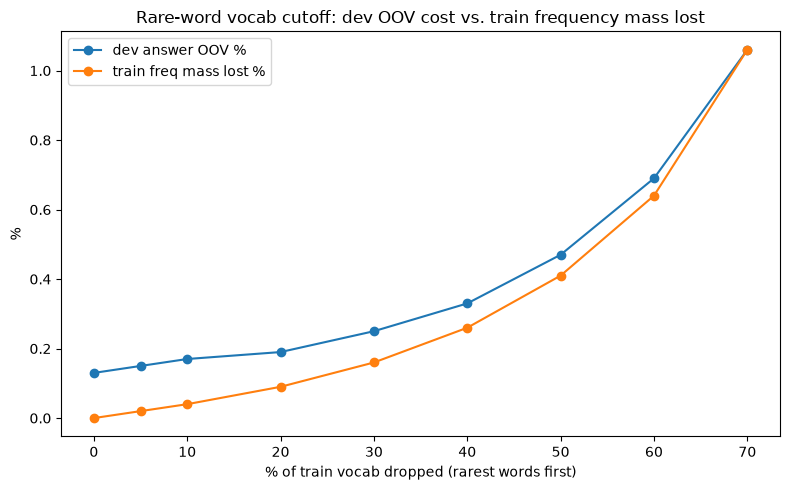

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cutoff_df.index, cutoff_df["dev_oov_pct"], marker="o", label="dev answer OOV %")
ax.plot(cutoff_df.index, 100 - cutoff_df["train_freq_mass_kept_pct"], marker="o", label="train freq mass lost %")
ax.set_xlabel("% of train vocab dropped (rarest words first)")
ax.set_ylabel("%")
ax.set_title("Rare-word vocab cutoff: dev OOV cost vs. train frequency mass lost")
ax.legend()
plt.tight_layout()
plt.show()

## Bracket answers in test: how many rows need `[` / `]`?

test has no `answer` column, but `first letter` tells us how many rows expect a bracket answer.

In [13]:
first_letter_counts = Counter()
with open(DATA / "test_set_no_answer_final.csv", newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        first_letter_counts[row["first letter"]] += 1

total_test_rows = sum(first_letter_counts.values())
for letter in ["[", "]"]:
    n = first_letter_counts[letter]
    print(f"first letter == {letter!r}: {n} rows ({100*n/total_test_rows:.2f}% of test)")

first letter == '[': 353 rows (0.37% of test)
first letter == ']': 60 rows (0.06% of test)
